In [ ]:
!pip install wfdb scipy pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
!wget -r -N -c -np https://physionet.org/files/challenge-2017/1.0.0/

Streaming output truncated to the last 5000 lines.
Length: 84 [text/plain]
Saving to: ‘physionet.org/files/challenge-2017/1.0.0/training/A08/A08279.hea’

physionet.org/files 100%[===================>]      84  --.-KB/s    in 0s      

2026-05-01 12:10:11 (20.9 MB/s) - ‘physionet.org/files/challenge-2017/1.0.0/training/A08/A08279.hea’ saved [84/84]

--2026-05-01 12:10:11--  https://physionet.org/files/challenge-2017/1.0.0/training/A08/A08279.mat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 36024 (35K) [text/plain]
Saving to: ‘physionet.org/files/challenge-2017/1.0.0/training/A08/A08279.mat’

physionet.org/files 100%[===================>]  35.18K  --.-KB/s    in 0.1s    

2026-05-01 12:10:11 (272 KB/s) - ‘physionet.org/files/challenge-2017/1.0.0/training/A08/A08279.mat’ saved [36024/36024]

--2026-05-01 12:10:11--  https://physionet.org/files/challenge-2017/1.0.0/training/A08/A08280.hea
Reusing existing connection to physionet.o

In [ ]:
!wget -O training2017.zip https://physionet.org/files/challenge-2017/1.0.0/training2017.zip

--2026-05-02 16:31:16--  https://physionet.org/files/challenge-2017/1.0.0/training2017.zip
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99226822 (95M) [application/zip]
Saving to: ‘training2017.zip’

training2017.zip    100%[===================>]  94.63M   197KB/s    in 12m 16s 

2026-05-02 16:43:33 (132 KB/s) - ‘training2017.zip’ saved [99226822/99226822]



In [ ]:
!unzip training2017.zip

Streaming output truncated to the last 5000 lines.
  inflating: training2017/A06030.mat  
  inflating: training2017/A06031.hea  
  inflating: training2017/A06031.mat  
  inflating: training2017/A06032.hea  
  inflating: training2017/A06032.mat  
  inflating: training2017/A06033.hea  
  inflating: training2017/A06033.mat  
  inflating: training2017/A06034.hea  
  inflating: training2017/A06034.mat  
  inflating: training2017/A06035.hea  
  inflating: training2017/A06035.mat  
  inflating: training2017/A06036.hea  
  inflating: training2017/A06036.mat  
  inflating: training2017/A06037.hea  
  inflating: training2017/A06037.mat  
  inflating: training2017/A06038.hea  
  inflating: training2017/A06038.mat  
  inflating: training2017/A06039.hea  
  inflating: training2017/A06039.mat  
  inflating: training2017/A06040.hea  
  inflating: training2017/A06040.mat  
  inflating: training2017/A06041.hea  
  inflating: training2017/A06041.mat  
  inflating: training2017/A06042.hea  
  inflating: 

In [ ]:
!ls

sample_data  training2017  training2017.zip


In [ ]:
import os
print(len(os.listdir("training2017")))

17059


In [ ]:
!find . -name "REFERENCE*.csv"

./training2017/REFERENCE-original.csv
./training2017/REFERENCE.csv


In [ ]:
!find / -name "REFERENCE*" 2>/dev/null

/content/training2017/REFERENCE-original.csv
/content/training2017/REFERENCE.csv


In [ ]:
import pandas as pd

labels_df = pd.read_csv(
    "/content/training2017/REFERENCE.csv",
    header=None,
    names=["record", "label"]
)

In [ ]:
import os
import numpy as np
from scipy.io import loadmat

base_path = "/content/training2017"

X = []
Y = []

label_map = {'N':0, 'A':1, 'O':2, '~':3}

In [ ]:
for i in range(len(labels_df)):
    record = labels_df.iloc[i]["record"]
    label = labels_df.iloc[i]["label"]

    file_path = os.path.join(base_path, record + ".mat")

    mat = loadmat(file_path)
    signal = mat["val"][0]

    X.append(signal)
    Y.append(label_map[label])

In [ ]:
MAX_LEN = 9000

def pad(sig):
    if len(sig) > MAX_LEN:
        return sig[:MAX_LEN]
    else:
        return np.pad(sig, (0, MAX_LEN - len(sig)))

X = np.array([pad(x) for x in X])
Y = np.array(Y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(9000,1)),
    MaxPooling1D(2),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# batch size = 128, epoch = 2
history_1 = model.fit(
    X_train[..., np.newaxis],
    Y_train,
    epochs=2,
    batch_size=128,
    validation_data=(X_test[..., np.newaxis], Y_test)
)

Epoch 1/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9697 - loss: 0.1138 - val_accuracy: 0.4660 - val_loss: 3.2658
Epoch 2/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.9875 - loss: 0.0561 - val_accuracy: 0.4771 - val_loss: 3.8545


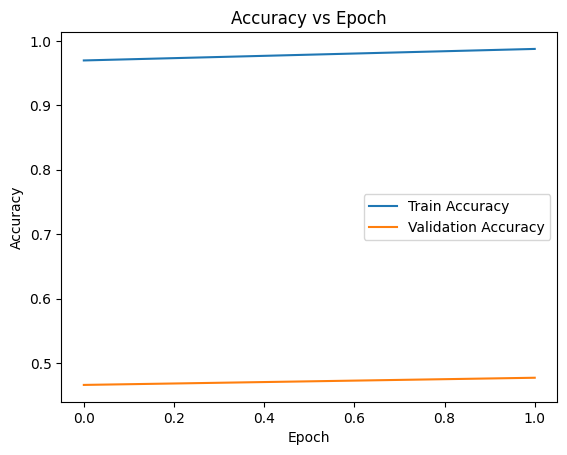

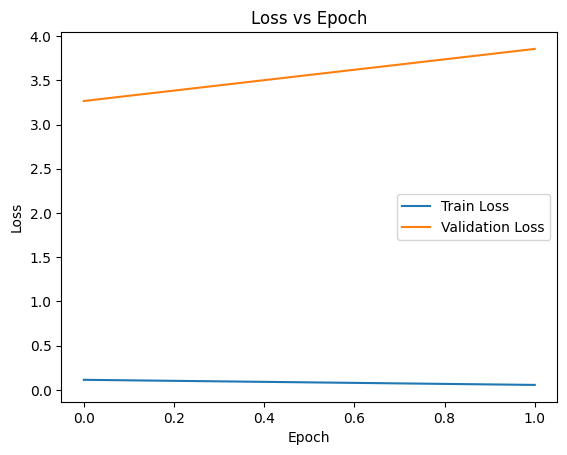

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch')
plt.show()

# Loss
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()

In [ ]:
# batch size = 128, epoch = 4
history_2 = model.fit(
    X_train[..., np.newaxis],
    Y_train,
    epochs=4,
    batch_size=128,
    validation_data=(X_test[..., np.newaxis], Y_test)
)

Epoch 1/4
54/54 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.9918 - loss: 0.0371 - val_accuracy: 0.4760 - val_loss: 4.1997
Epoch 2/4
54/54 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9940 - loss: 0.0278 - val_accuracy: 0.4795 - val_loss: 4.6930
Epoch 3/4
54/54 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9969 - loss: 0.0201 - val_accuracy: 0.4766 - val_loss: 5.0062
Epoch 4/4
54/54 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.9974 - loss: 0.0155 - val_accuracy: 0.4760 - val_loss: 5.2993


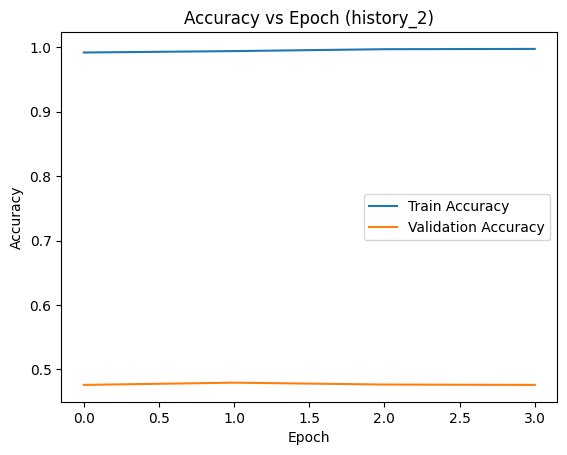

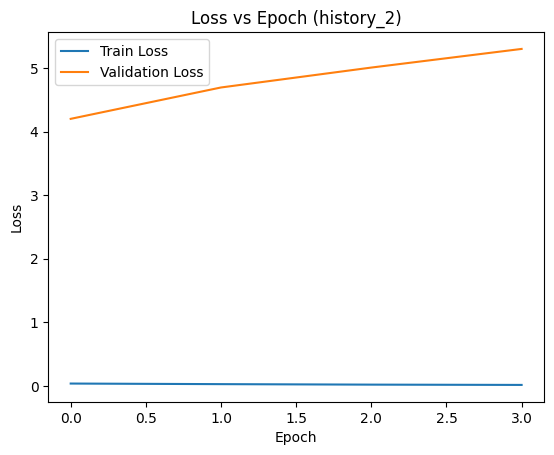

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch (history_2)')
plt.show()

# Loss
plt.figure()
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch (history_2)')
plt.show()

In [ ]:
# batch size = 256, epochs = 2
history_3 = model.fit(
    X_train[..., np.newaxis],
    Y_train,
    epochs=2,
    batch_size=256,
    validation_data=(X_test[..., np.newaxis], Y_test)
)

Epoch 1/2
27/27 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.9746 - loss: 0.1190 - val_accuracy: 0.4760 - val_loss: 3.3900
Epoch 2/2
27/27 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 0.9944 - loss: 0.0408 - val_accuracy: 0.4877 - val_loss: 4.1782


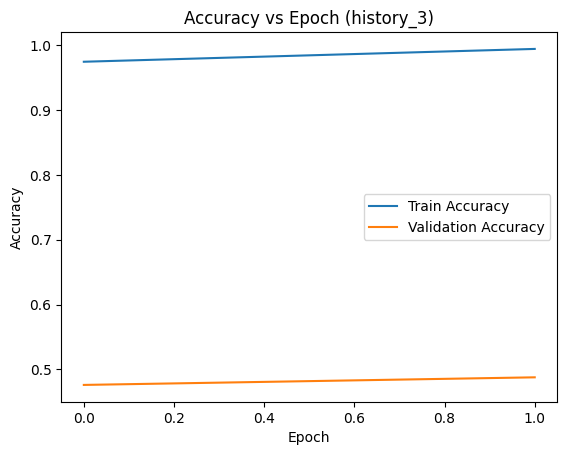

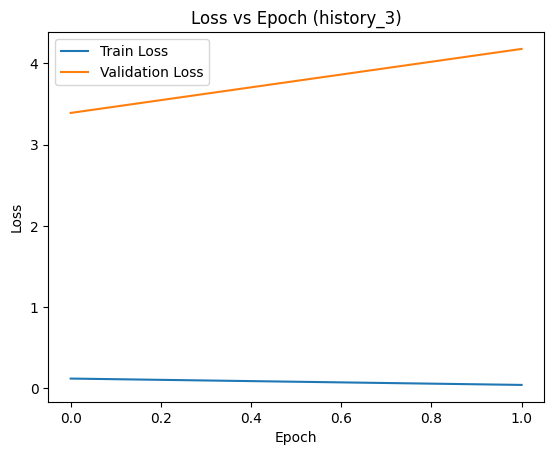

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch (history_3)')
plt.show()

# Loss
plt.figure()
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch (history_3)')
plt.show()

In [ ]:
# batch size = 256, epoch = 4
history_4 = model.fit(
    X_train[..., np.newaxis],
    Y_train,
    epochs=4,
    batch_size=256,
    validation_data=(X_test[..., np.newaxis], Y_test)
)

Epoch 1/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 159s 6s/step - accuracy: 0.9971 - loss: 0.0226 - val_accuracy: 0.4818 - val_loss: 4.5355
Epoch 2/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 159s 6s/step - accuracy: 0.9985 - loss: 0.0152 - val_accuracy: 0.4760 - val_loss: 4.8707
Epoch 3/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.9990 - loss: 0.0119 - val_accuracy: 0.4818 - val_loss: 5.1617
Epoch 4/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 144s 5s/step - accuracy: 0.9990 - loss: 0.0097 - val_accuracy: 0.4824 - val_loss: 5.4047


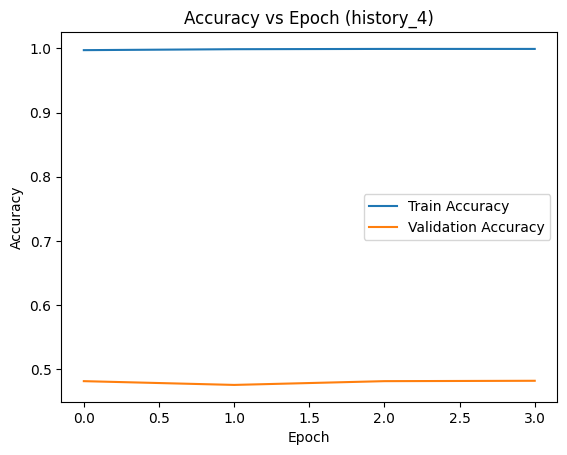

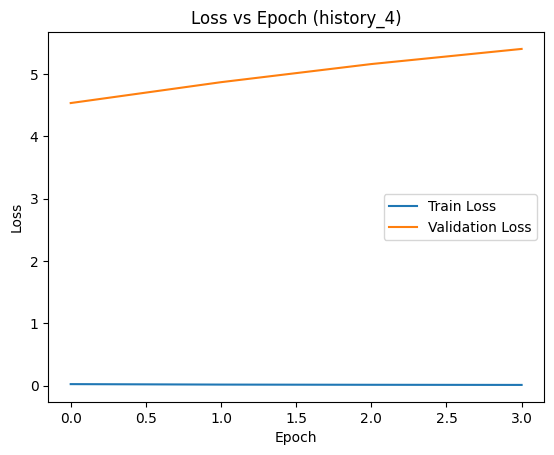

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch (history_4)')
plt.show()

# Loss
plt.figure()
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch (history_4)')
plt.show()

In [ ]:
# batch size = 32, epoch = 3
history_5 = model.fit(
    X_train[..., np.newaxis],
    Y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test[..., np.newaxis], Y_test)
)

Epoch 1/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 170s 792ms/step - accuracy: 0.9984 - loss: 0.0105 - val_accuracy: 0.4713 - val_loss: 5.1547
Epoch 2/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 167s 780ms/step - accuracy: 0.9875 - loss: 0.0487 - val_accuracy: 0.4982 - val_loss: 4.3553
Epoch 3/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 169s 788ms/step - accuracy: 0.9729 - loss: 0.1026 - val_accuracy: 0.4818 - val_loss: 4.6389


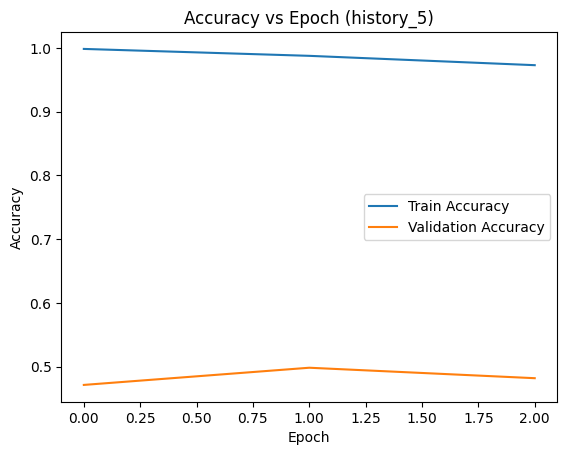

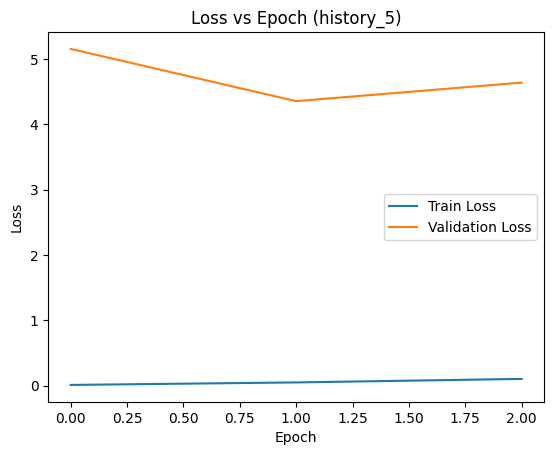

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch (history_5)')
plt.show()

# Loss
plt.figure()
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch (history_5)')
plt.show()